In [1]:
import pandas as pd
import os

processed_path = r"C:\Users\Pawan\OneDrive\Desktop\Online-Retail-II\Online-retail-demand-forecasting\data\processed"

sales_df = pd.read_csv(
    os.path.join(processed_path, "sales_transactions_cleaned.csv")
)

sales_df.shape

(9959019, 12)

In [2]:
yearly_sales = sales_df.groupby('year')['total_value'].sum()

yearly_sales

year
2022    2.579511e+09
2023    2.629744e+09
2024    2.682772e+09
2025    3.010882e+09
Name: total_value, dtype: float64

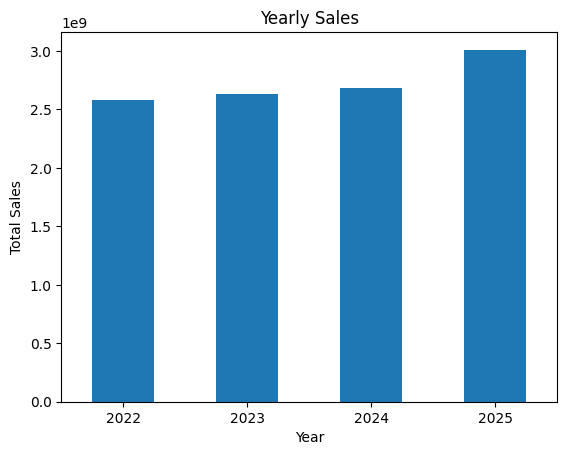

In [3]:
import matplotlib.pyplot as plt

yearly_sales.plot(kind='bar')

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [4]:
sales_df['date'] = pd.to_datetime(sales_df['date'])

In [5]:
sales_df['date'].dtype

dtype('<M8[us]')

In [6]:
sales_df['month'] = sales_df['date'].dt.month

monthly_sales = sales_df.groupby('month')['total_value'].sum()

monthly_sales

month
1     7.607197e+08
2     6.950876e+08
3     7.864319e+08
4     8.133988e+08
5     9.088184e+08
6     8.318062e+08
7     8.270876e+08
8     9.257153e+08
9     9.566928e+08
10    9.665832e+08
11    1.147445e+09
12    1.283123e+09
Name: total_value, dtype: float64

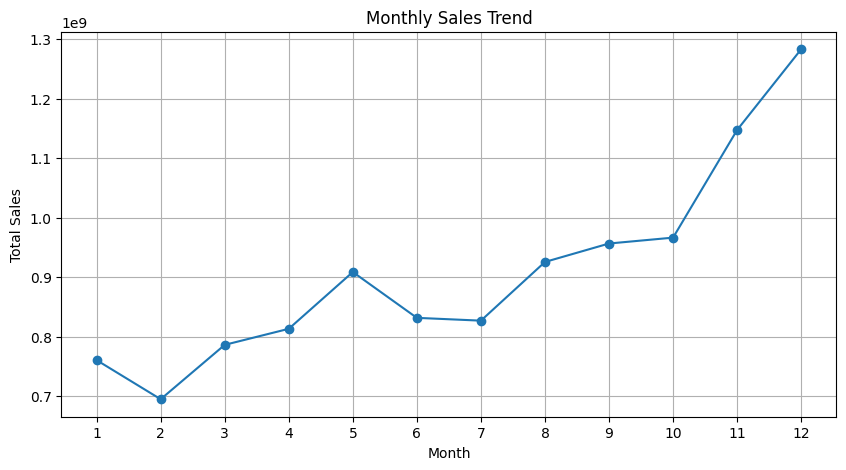

In [7]:
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [8]:
store_sales = (
    sales_df.groupby('store_id')['total_value']
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

store_id
ST07    5.191603e+08
ST06    5.173233e+08
ST29    5.171921e+08
ST22    5.168133e+08
ST20    5.152791e+08
ST30    5.146105e+08
ST21    5.140025e+08
ST05    3.896599e+08
ST18    3.891568e+08
ST27    3.883785e+08
Name: total_value, dtype: float64

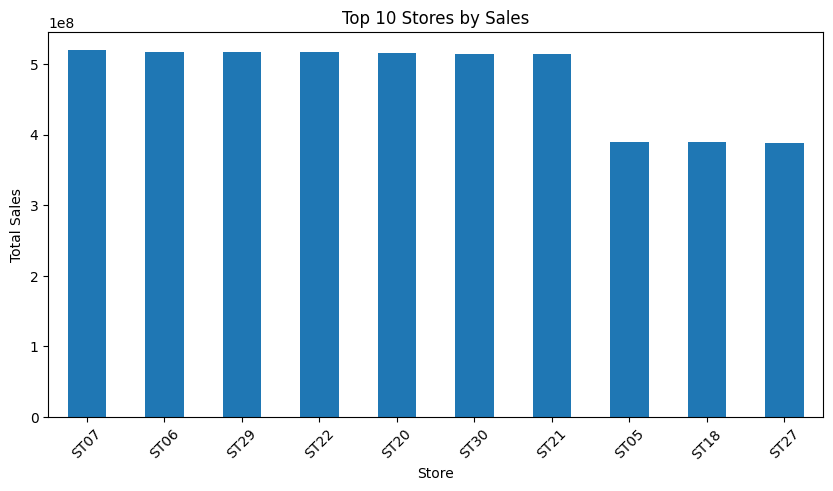

In [9]:
store_sales.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [10]:
product_sales = (
    sales_df.groupby('sku_id')['total_value']
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

sku_id
SKU04321    1.066898e+09
SKU03727    2.614215e+08
SKU04329    9.468604e+07
SKU04596    8.894259e+07
SKU01371    8.408248e+07
SKU03053    8.407665e+07
SKU01189    7.029371e+07
SKU04551    6.920131e+07
SKU04157    6.910185e+07
SKU04571    6.249078e+07
Name: total_value, dtype: float64

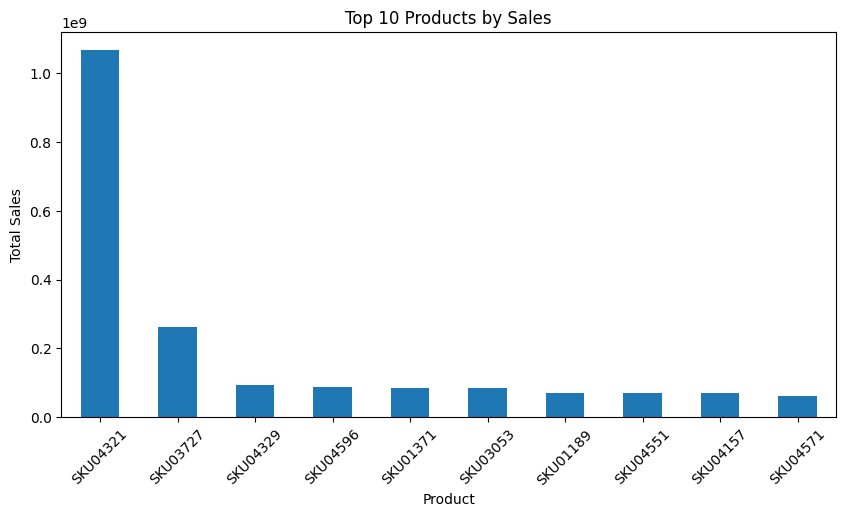

In [11]:
product_sales.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [12]:
channel_sales = (
    sales_df.groupby('channel')['total_value']
    .sum()
    .sort_values(ascending=False)
)

channel_sales

channel
In-Store      6.024828e+09
Online        3.242131e+09
Mobile App    1.635949e+09
Name: total_value, dtype: float64

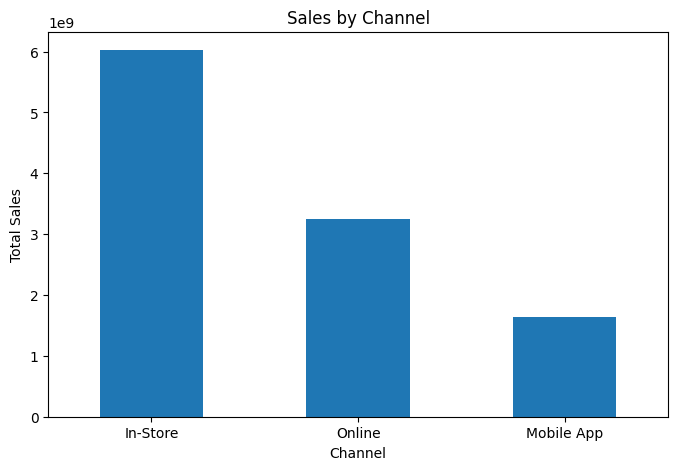

In [13]:
channel_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [14]:
sales_df['promotion_status'] = sales_df['promo_id'].apply(
    lambda x: 'No Promotion' if x == 'No Promotion' else 'Promotion'
)

promotion_sales = (
    sales_df.groupby('promotion_status')['total_value']
    .sum()
    .sort_values(ascending=False)
)

promotion_sales

promotion_status
No Promotion    9.162973e+09
Promotion       1.739936e+09
Name: total_value, dtype: float64

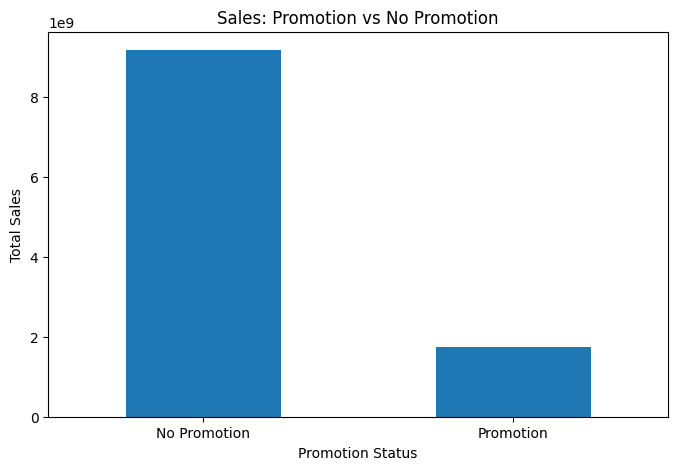

In [15]:
promotion_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales: Promotion vs No Promotion')
plt.xlabel('Promotion Status')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [16]:
discount_sales = (
    sales_df.groupby('discount_pct')['total_value']
    .sum()
    .sort_index()
)

discount_sales.head(10)

discount_pct
0.0    9.162973e+09
5.0    1.742650e+04
5.8    3.622755e+06
5.9    2.669781e+06
6.8    3.752542e+06
7.0    6.226738e+07
7.9    2.027172e+06
8.1    2.684123e+06
8.5    1.951763e+07
8.6    5.198867e+07
Name: total_value, dtype: float64

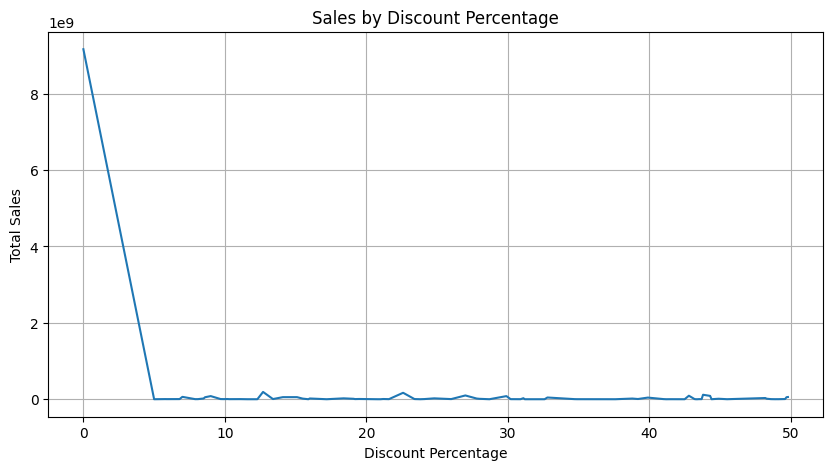

In [17]:
discount_sales.plot(
    kind='line',
    figsize=(10,5)
)

plt.title('Sales by Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [18]:
customer_sales = (
    sales_df.groupby('customer_id')['total_value']
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

customer_id
CUST01883    2588854.88
CUST03371    2587491.74
CUST08853    2565075.89
CUST06744    2555364.56
CUST02140    2552445.08
CUST00962    2547226.70
CUST04307    2539284.46
CUST01437    2538836.53
CUST05663    2538462.23
CUST04447    2524960.56
Name: total_value, dtype: float64

In [19]:
daily_sales = (
    sales_df.groupby('date')['total_value']
    .sum()
    .reset_index()
)

daily_sales.head()

,date,total_value
0,2022-01-01,5796378.22
1,2022-01-02,5926177.21
2,2022-01-03,6028251.58
3,2022-01-04,5844144.77
4,2022-01-05,5830410.96


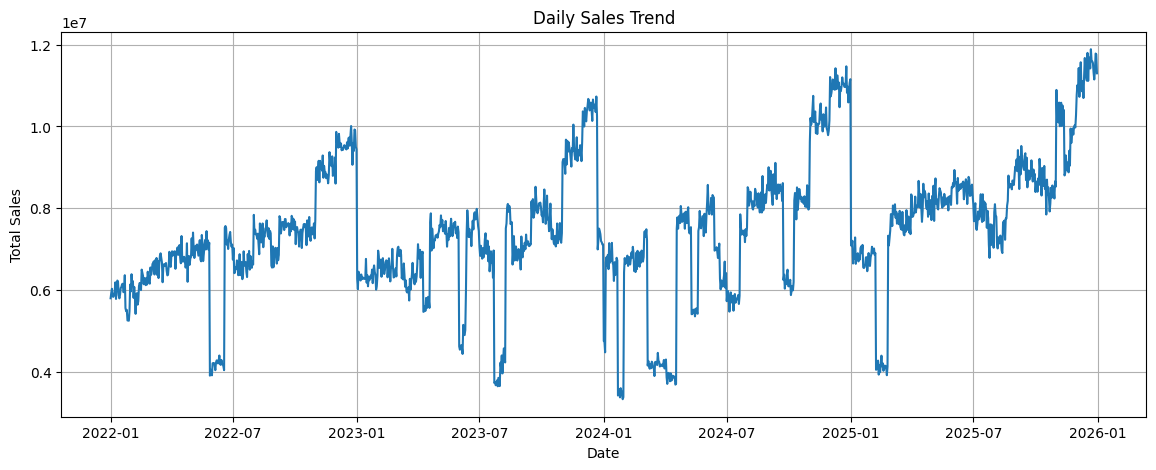

In [20]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_sales['date'],
    daily_sales['total_value']
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


In [21]:
monthly_avg_sales = (
    sales_df.groupby('month')['total_value']
    .mean()
)

monthly_avg_sales

month
1     1099.584038
2     1068.540326
3     1022.059599
4     1057.364506
5     1120.387996
6     1020.775101
7     1074.076939
8     1086.219485
9     1119.955446
10    1134.917611
11    1150.694474
12    1138.968956
Name: total_value, dtype: float64

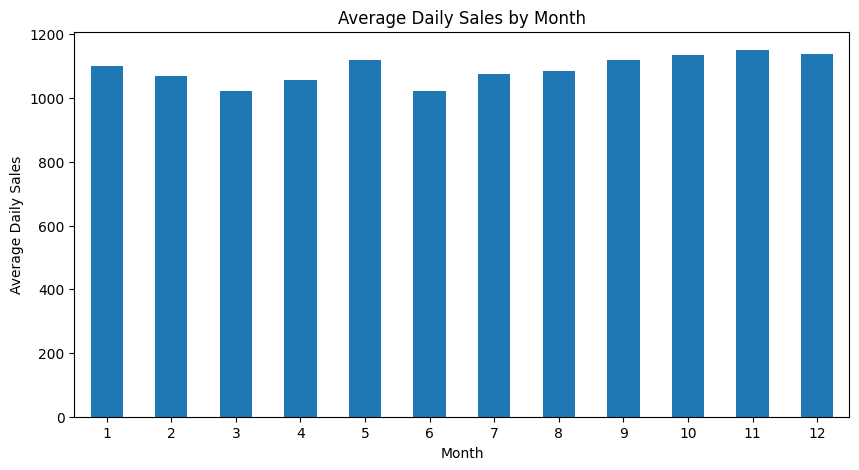

In [22]:
monthly_avg_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Daily Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales')
plt.xticks(range(12), range(1, 13), rotation=0)
plt.show()

In [23]:
daily_demand = (
    sales_df.groupby('date')
    .agg(
        demand=('quantity', 'sum'),
        sales=('total_value', 'sum'),
        transactions=('receipt_id', 'nunique')
    )
    .reset_index()
)

daily_demand.head()

,date,demand,sales,transactions
0,2022-01-01,9529,5796378.22,2615
1,2022-01-02,9637,5926177.21,2667
2,2022-01-03,9679,6028251.58,2677
3,2022-01-04,9749,5844144.77,2600
4,2022-01-05,9320,5830410.96,2613


In [24]:
daily_demand['year'] = daily_demand['date'].dt.year
daily_demand['month'] = daily_demand['date'].dt.month
daily_demand['quarter'] = daily_demand['date'].dt.quarter
daily_demand['day_of_week'] = daily_demand['date'].dt.dayofweek
daily_demand['day'] = daily_demand['date'].dt.day
daily_demand['week_of_year'] = daily_demand['date'].dt.isocalendar().week.astype(int)

daily_demand['is_weekend'] = (
    daily_demand['day_of_week'] >= 5
).astype(int)

daily_demand.head()

,date,demand,sales,transactions,year,month,quarter,day_of_week,day,week_of_year,is_weekend
0,2022-01-01,9529,5796378.22,2615,2022,1,1,5,1,52,1
1,2022-01-02,9637,5926177.21,2667,2022,1,1,6,2,52,1
2,2022-01-03,9679,6028251.58,2677,2022,1,1,0,3,1,0
3,2022-01-04,9749,5844144.77,2600,2022,1,1,1,4,1,0
4,2022-01-05,9320,5830410.96,2613,2022,1,1,2,5,1,0


In [25]:
daily_demand.shape

(1461, 11)

In [26]:
daily_demand['lag_1'] = daily_demand['demand'].shift(1)
daily_demand['lag_7'] = daily_demand['demand'].shift(7)
daily_demand['lag_14'] = daily_demand['demand'].shift(14)
daily_demand['lag_30'] = daily_demand['demand'].shift(30)

daily_demand.head(35)

,date,demand,sales,transactions,year,month,quarter,day_of_week,day,week_of_year,is_weekend,lag_1,lag_7,lag_14,lag_30
0,2022-01-01,9529,5796378.22,2615,2022,1,1,5,1,52,1,NaN,NaN,NaN,NaN
1,2022-01-02,9637,5926177.21,2667,2022,1,1,6,2,52,1,9529.0,NaN,NaN,NaN
2,2022-01-03,9679,6028251.58,2677,2022,1,1,0,3,1,0,9637.0,NaN,NaN,NaN
3,2022-01-04,9749,5844144.77,2600,2022,1,1,1,4,1,0,9679.0,NaN,NaN,NaN
4,2022-01-05,9320,5830410.96,2613,2022,1,1,2,5,1,0,9749.0,NaN,NaN,NaN
5,2022-01-06,9464,5862412.67,2659,2022,1,1,3,6,1,0,9320.0,NaN,NaN,NaN
6,2022-01-07,9563,5938102.09,2643,2022,1,1,4,7,1,0,9464.0,NaN,NaN,NaN
7,2022-01-08,9640,6185634.77,2728,2022,1,1,5,8,1,1,9563.0,9529.0,NaN,NaN
8,2022-01-09,9249,5779960.50,2543,2022,1,1,6,9,1,1,9640.0,9637.0,NaN,NaN
9,2022-01-10,9605,6043313.17,2674,2022,1,1,0,10,2,0,9249.0,9679.0,NaN,NaN


In [27]:
daily_demand['rolling_7'] = daily_demand['demand'].shift(1).rolling(7).mean()
daily_demand['rolling_14'] = daily_demand['demand'].shift(1).rolling(14).mean()
daily_demand['rolling_30'] = daily_demand['demand'].shift(1).rolling(30).mean()

daily_demand.head(35)

,date,demand,sales,transactions,year,month,quarter,day_of_week,day,week_of_year,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_7,rolling_14,rolling_30
0,2022-01-01,9529,5796378.22,2615,2022,1,1,5,1,52,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,9637,5926177.21,2667,2022,1,1,6,2,52,1,9529.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,9679,6028251.58,2677,2022,1,1,0,3,1,0,9637.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-04,9749,5844144.77,2600,2022,1,1,1,4,1,0,9679.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-05,9320,5830410.96,2613,2022,1,1,2,5,1,0,9749.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2022-01-06,9464,5862412.67,2659,2022,1,1,3,6,1,0,9320.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2022-01-07,9563,5938102.09,2643,2022,1,1,4,7,1,0,9464.0,NaN,NaN,NaN,NaN,NaN,NaN
7,2022-01-08,9640,6185634.77,2728,2022,1,1,5,8,1,1,9563.0,9529.0,NaN,NaN,9563.000000,NaN,NaN
8,2022-01-09,9249,5779960.50,2543,2022,1,1,6,9,1,1,9640.0,9637.0,NaN,NaN,9578.857143,NaN,NaN
9,2022-01-10,9605,6043313.17,2674,2022,1,1,0,10,2,0,9249.0,9679.0,NaN,NaN,9523.428571,NaN,NaN


In [28]:
daily_demand.isna().sum()

date             0
demand           0
sales            0
transactions     0
year             0
month            0
quarter          0
day_of_week      0
day              0
week_of_year     0
is_weekend       0
lag_1            1
lag_7            7
lag_14          14
lag_30          30
rolling_7        7
rolling_14      14
rolling_30      30
dtype: int64

In [29]:
daily_demand_model = daily_demand.dropna().copy()

print("Original rows:", len(daily_demand))
print("Rows for modeling:", len(daily_demand_model))
print("Missing values:", daily_demand_model.isna().sum().sum())

Original rows: 1461
Rows for modeling: 1431
Missing values: 0


In [30]:
daily_demand_model.columns

Index(['date', 'demand', 'sales', 'transactions', 'year', 'month', 'quarter',
       'day_of_week', 'day', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7',
       'lag_14', 'lag_30', 'rolling_7', 'rolling_14', 'rolling_30'],
      dtype='str')

In [31]:
# Sort by date
daily_demand_model = daily_demand_model.sort_values('date').reset_index(drop=True)

# Use the last 20% of the data for testing
split_index = int(len(daily_demand_model) * 0.8)

train = daily_demand_model.iloc[:split_index].copy()
test = daily_demand_model.iloc[split_index:].copy()

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("\nTraining period:")
print(train['date'].min(), "to", train['date'].max())

print("\nTesting period:")
print(test['date'].min(), "to", test['date'].max())

Training data: (1144, 18)
Testing data: (287, 18)

Training period:
2022-01-31 00:00:00 to 2025-03-19 00:00:00

Testing period:
2025-03-20 00:00:00 to 2025-12-31 00:00:00


In [32]:
features = [
    'year',
    'month',
    'quarter',
    'day_of_week',
    'day',
    'week_of_year',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',
    'rolling_7',
    'rolling_14',
    'rolling_30'
]

target = 'demand'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1144, 14)
y_train: (1144,)
X_test: (287, 14)
y_test: (287,)


In [33]:
print("Feature engineering completed successfully.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Feature engineering completed successfully.
Training samples: 1144
Testing samples: 287


In [34]:
forecasting_path = os.path.join(
    processed_path,
    "daily_demand_features.csv"
)

daily_demand_model.to_csv(
    forecasting_path,
    index=False
)

print("Forecasting dataset saved successfully.")

Forecasting dataset saved successfully.
